In [40]:
import sys
import os
sys.path += [ f'{os.environ["HOME"]}/.local/lib/python{sys.version_info.major}.{sys.version_info.minor}/site-packages' ]

# Now we can safely import atlasopenmagic
import atlasopenmagic as atom

In [41]:
import uproot # for reading .root files
import time # to measure time to analyse
import math # for mathematical functions such as square root
import awkward as ak # for handling complex and nested data structures efficiently
import numpy as np # # for numerical calculations such as histogramming
import matplotlib.pyplot as plt # for plotting
from matplotlib.ticker import MaxNLocator,AutoMinorLocator # for minor ticks
from lmfit.models import PolynomialModel, GaussianModel # for the signal and background fits
import vector #to use vectors
import requests # for HTTP access
import aiohttp # HTTP client support
import pandas as pd

In [42]:
atom.set_release('2025e-13tev-beta')

Release '2025e-13tev-beta' already active with cached metadata.
Active release: 2025e-13tev-beta. (Datasets path: REMOTE)


In [43]:
lumi = 36
# process the entire dataset
fraction = 1

In [44]:
# Now let's find Zprime samples
atom.match_metadata(field='keywords',value='Zprime')

[('301204', 'Pythia8EvtGen_A14MSTW2008LO_Zprime_NoInt_ee_SSM3000'),
 ('301209', 'Pythia8EvtGen_A14MSTW2008LO_Zprime_NoInt_mumu_SSM3000'),
 ('301333', 'Pythia8EvtGen_A14NNPDF23LO_zprime3000_tt'),
 ('301928', 'Pythia8EvtGen_A14NNPDF23LO_Zprimebb3000'),
 ('801976', 'Py8EG_A14NNPDF23LO_Zprime_NoInt_tautau_SSM3000')]

In [45]:
# Now let's find Drell Yan samples ee
atom.match_metadata(field='process',value='ee')

[('301204', 'Pythia8EvtGen_A14MSTW2008LO_Zprime_NoInt_ee_SSM3000'),
 ('345876', 'PowhegPythia8EvtGen_NNPDF30_AZNLO_ZH125J_Hee__Zincl_MINLO'),
 ('345877', 'PowhegPythia8EvtGen_NNPDF30_AZNLO_WpH125J_Hee_Wincl_MINLO'),
 ('345878', 'PowhegPythia8EvtGen_NNPDF30_AZNLO_WmH125J_Hee_Wincl_MINLO'),
 ('346446', 'PhH7EG_H7UE_NNLOPS_nnlo_30_ggH125_ZZ4l_noTau'),
 ('410218', 'aMcAtNloPythia8EvtGen_MEN30NLO_A14N23LO_ttee'),
 ('700195', 'Sh_2210_eegammagamma'),
 ('700320', 'Sh_2211_Zee_maxHTpTV2_BFilter'),
 ('700321', 'Sh_2211_Zee_maxHTpTV2_CFilterBVeto'),
 ('700322', 'Sh_2211_Zee_maxHTpTV2_CVetoBVeto'),
 ('700358', 'Sh_2211_Zee2jets_Min_N_TChannel'),
 ('700399', 'Sh_2211_eegamma'),
 ('700467', 'Sh_2211_Zee_maxHTpTV2_m10_40_pT5_BFilter'),
 ('700468', 'Sh_2211_Zee_maxHTpTV2_m10_40_pT5_CFilterBVeto'),
 ('700469', 'Sh_2211_Zee_maxHTpTV2_m10_40_pT5_CVetoBVeto')]

In [46]:
# Now let's find Drell Yan samples mumu
atom.match_metadata(field='process',value='mumu')

[('345097', 'PowhegPythia8EvtGen_NNLOPS_nnlo_30_ggH125_mumu'),
 ('345098', 'PowhegPythia8EvtGen_NNPDF3_AZNLO_ggZH125_Hmumu_Zinc'),
 ('345103', 'PowhegPythia8EvtGen_NNPDF30_AZNLO_ZH125J_Hmumu_Zincl_MINLO'),
 ('345104', 'PowhegPythia8EvtGen_NNPDF30_AZNLO_WpH125J_Hmumu_Wincl_MINLO'),
 ('345105', 'PowhegPythia8EvtGen_NNPDF30_AZNLO_WmH125J_Hmumu_Wincl_MINLO'),
 ('345106', 'PowhegPythia8EvtGen_NNPDF30_AZNLOCTEQ6L1_VBFH125_mumu'),
 ('346446', 'PhH7EG_H7UE_NNLOPS_nnlo_30_ggH125_ZZ4l_noTau'),
 ('410219', 'aMcAtNloPythia8EvtGen_MEN30NLO_A14N23LO_ttmumu'),
 ('700196', 'Sh_2210_mumugammagamma'),
 ('700323', 'Sh_2211_Zmumu_maxHTpTV2_BFilter'),
 ('700324', 'Sh_2211_Zmumu_maxHTpTV2_CFilterBVeto'),
 ('700325', 'Sh_2211_Zmumu_maxHTpTV2_CVetoBVeto'),
 ('700359', 'Sh_2211_Zmm2jets_Min_N_TChannel'),
 ('700398', 'Sh_2211_mumugamma'),
 ('700470', 'Sh_2211_Zmumu_maxHTpTV2_m10_40_pT5_BFilter'),
 ('700471', 'Sh_2211_Zmumu_maxHTpTV2_m10_40_pT5_CFilterBVeto'),
 ('700472', 'Sh_2211_Zmumu_maxHTpTV2_m10_40_pT5_CVet

In [47]:
# Now let's find Drell Yan samples mumu
atom.match_metadata(field='process',value='Z')

[('301204', 'Pythia8EvtGen_A14MSTW2008LO_Zprime_NoInt_ee_SSM3000'),
 ('301209', 'Pythia8EvtGen_A14MSTW2008LO_Zprime_NoInt_mumu_SSM3000'),
 ('301333', 'Pythia8EvtGen_A14NNPDF23LO_zprime3000_tt'),
 ('301928', 'Pythia8EvtGen_A14NNPDF23LO_Zprimebb3000'),
 ('341456', 'PowhegPythia8EvtGen_CT10_AZNLO_ZH125J_MINLO_veveWWlvqq_VpT'),
 ('341458', 'PowhegPythia8EvtGen_CT10_AZNLO_ZH125J_MINLO_vmuvmuWWlvqq_VpT'),
 ('341460', 'PowhegPy8EG_CT10_AZNLO_ZH125J_MINLO_vtauvtauWWlvqq_VpT'),
 ('345056', 'PowhegPythia8EvtGen_NNPDF3_AZNLO_ZH125J_MINLO_vvbb_VpT'),
 ('345058', 'PowhegPythia8EvtGen_NNPDF3_AZNLO_ggZH125_vvbb'),
 ('345060', 'PowhegPythia8EvtGen_NNLOPS_nnlo_30_ggH125_ZZ4l'),
 ('345061', 'PowhegPythia8EvtGen_NNPDF3_AZNLO_ggZH125_HgamgamZinc'),
 ('345066', 'PowhegPythia8EvtGen_NNPDF3_AZNLO_ggZH125_ZZ4lepZinc'),
 ('345098', 'PowhegPythia8EvtGen_NNPDF3_AZNLO_ggZH125_Hmumu_Zinc'),
 ('345103', 'PowhegPythia8EvtGen_NNPDF30_AZNLO_ZH125J_Hmumu_Zincl_MINLO'),
 ('345112', 'PowhegPythia8EvtGen_NNPDF3_AZNLO_ZH12

In [48]:
# list with signal DSIDs: ee, mumu
# should tautau, bb, tt be included?
dsid_signal_list = [301209] 
dsid_background_list = [700323, 700324, 700325, 700470, 700471, 700472] # remove tt, 410219]
dsid_background_list = [700323, 700324, 700325, 700470, 700471, 700472, 410219, 700589, 700602, 601624, 601628]

In [49]:
for dsid in dsid_signal_list:
    print(atom.get_metadata(dsid))

{'dataset_number': '301209', 'physics_short': 'Pythia8EvtGen_A14MSTW2008LO_Zprime_NoInt_mumu_SSM3000', 'e_tag': 'e3723', 'cross_section_pb': 0.0017718, 'genFiltEff': 1.0, 'kFactor': 1.0, 'nEvents': 20000, 'sumOfWeights': 20000.0, 'sumOfWeightsSquared': 20000.0, 'process': 'pp>Zprime>mm', 'generator': 'Pythia8(v8.186)+EvtGen(v1.2.0)', 'keywords': ['2muon', 'BSM', 'SSM', 'Zprime', 'electroweak', 'heavyBoson', 'resonance'], 'description': 'Pythia 8 Zprime decaying to two muons', 'job_path': 'https://gitlab.cern.ch/atlas-physics/pmg/infrastructure/mc15joboptions/-/tree/master/share/DSID301xxx/MC15.301209.Pythia8EvtGen_A14MSTW2008LO_Zprime_NoInt_mumu_SSM3000.py', 'CoMEnergy': 13000.0, 'GenEvents': None, 'GenTune': 'A14', 'PDF': 'MSTW2008LO', 'Release': 'AtlasProduction_19.2.1.6,e3723_s3681_r13167_p6026', 'Filters': None, 'cross_section_uncertainty': 0.0, 'hepmc_version': None, 'release': {'name': '2025e-13tev-beta'}}


In [50]:
for dsid in dsid_background_list:
    print(atom.get_metadata(dsid))

{'dataset_number': '700323', 'physics_short': 'Sh_2211_Zmumu_maxHTpTV2_BFilter', 'e_tag': 'e8351', 'cross_section_pb': 2221.3, 'genFiltEff': 0.02439439, 'kFactor': 1.0, 'nEvents': 4009800, 'sumOfWeights': 12741690203522.818, 'sumOfWeightsSquared': 8.070834386859773e+20, 'process': 'Z->mumu with b-quarks', 'generator': 'Sherpa', 'keywords': ['2muon', 'NLO', 'SM', 'Z', 'jets'], 'description': 'Sherpa Z/gamma* -> mu mu + 0,1,2j@NLO + 3,4,5j@LO with b-jet filter taking input from existing unfiltered input file.', 'job_path': 'https://gitlab.cern.ch/atlas-physics/pmg/mcjoboptions/-/blob/master/700xxx/700323/mc.Sh_2211_Zmumu_maxHTpTV2_BFilter.py', 'CoMEnergy': 13000.0, 'GenEvents': None, 'GenTune': 'Sherpa 2.2.11', 'PDF': 'NNPDF30NNLO', 'Release': 'AthGeneration_21.6.70,e8351_s3681_r13167_p6026', 'Filters': 'HeavyFlavorBHadronFilter', 'cross_section_uncertainty': 0.0, 'hepmc_version': None, 'release': {'name': '2025e-13tev-beta'}}
{'dataset_number': '700324', 'physics_short': 'Sh_2211_Zmumu_

In [51]:
atom.get_metadata(700320)

{'dataset_number': '700320',
 'physics_short': 'Sh_2211_Zee_maxHTpTV2_BFilter',
 'e_tag': 'e8351',
 'cross_section_pb': 2221.2,
 'genFiltEff': 0.02493594,
 'kFactor': 1.0,
 'nEvents': 4206400,
 'sumOfWeights': 13590815498198.059,
 'sumOfWeightsSquared': 8.425539971958584e+20,
 'process': 'Z->ee with b-quarks',
 'generator': 'Sherpa',
 'keywords': ['2electron', 'NLO', 'SM', 'Z', 'jets'],
 'description': 'Sherpa Z/gamma* -> e e + 0,1,2j@NLO + 3,4,5j@LO with b-jet filter taking input from existing unfiltered input file.',
 'job_path': 'https://gitlab.cern.ch/atlas-physics/pmg/mcjoboptions/-/blob/master/700xxx/700320/mc.Sh_2211_Zee_maxHTpTV2_BFilter.py',
 'CoMEnergy': 13000.0,
 'GenEvents': None,
 'GenTune': 'Sherpa 2.2.11',
 'PDF': 'NNPDF30NNLO',
 'Release': 'AthGeneration_21.6.70,e8351_s3681_r13167_p6026',
 'Filters': 'HeavyFlavorBHadronFilter',
 'cross_section_uncertainty': 0.0,
 'hepmc_version': None,
 'release': {'name': '2025e-13tev-beta'}}

In [52]:
xsec = atom.get_metadata('700320', 'cross_section_pb')
xsec

2221.2

In [53]:
def calc_dilepton_mass(lep_pt, lep_eta, lep_phi, lep_e):
    # first lepton is [0], 2nd lepton is [1] etc
    px_0 = lep_pt[0]*math.cos(lep_phi[0]) # x-component of lep[0] momentum
    py_0 = lep_pt[0]*math.sin(lep_phi[0]) # y-component of lep[0] momentum
    pz_0 = lep_pt[0]*math.sinh(lep_eta[0]) # z-component of lep[0] momentum
    px_1 = lep_pt[1]*math.cos(lep_phi[1]) # x-component of lep[1] momentum
    py_1 = lep_pt[1]*math.sin(lep_phi[1]) # y-component of lep[1] momentum
    pz_1 = lep_pt[1]*math.sinh(lep_eta[1]) # z-component of lep[1] momentum
    sumpx = px_0 + px_1 # x-component of 4-lepton momentum
    sumpy = py_0 + py_1 # y-component of 4-lepton momentum
    sumpz = pz_0 + pz_1 # z-component of 4-lepton momentum
    sumE = lep_e[0] + lep_e[1] # energy of 4-lepton system
    rad = sumE**2 - sumpx**2 - sumpy**2 - sumpz**2
    if rad < 0: rad = 0
    return math.sqrt(rad) #/1000 to go from MeV to GeV


def calc_leading_lep_eta(lep_pt, lep_eta):
    if lep_pt[0] > lep_pt[1]:
        return lep_eta[0]
    else:
        return lep_eta[1]

def calc_subleading_lep_eta(lep_pt, lep_eta):
    if lep_pt[0] < lep_pt[1]:
        return lep_eta[0]
    else:
        return lep_eta[1]

def calc_leading_lep_phi(lep_pt, lep_phi):
    if lep_pt[0] > lep_pt[1]:
        return lep_phi[0]
    else:
        return lep_phi[1]

def calc_subleading_lep_phi(lep_pt, lep_phi):
    if lep_pt[0] < lep_pt[1]:
        return lep_phi[0]
    else:
        return lep_phi[1]

def calc_leading_lep_e(lep_pt, lep_e):
    if lep_pt[0] > lep_pt[1]:
        return lep_e[0]
    else:
        return lep_e[1]

def calc_subleading_lep_e(lep_pt, lep_e):
    if lep_pt[0] < lep_pt[1]:
        return lep_e[0]
    else:
        return lep_e[1]

def calc_deltaR(deltaeta, deltaphi):
    return np.sqrt(deltaeta**2 + deltaphi**2)

def calc_delta_phi(lep_phi):
    deltaphi = lep_phi[0] - lep_phi[1]
    if deltaphi < 0.0:
        deltaphi = -deltaphi
    if deltaphi > 2.0 * np.pi:
        deltaphi = deltaphi - 2.0 * np.pi
    if deltaphi >= np.pi:
        deltaphi = 2.0 * np.pi - deltaphi
    return deltaphi / np.pi


def calc_delta_eta(lep_eta):
    deltaeta = np.abs(lep_eta[0] - lep_eta[1])
    return deltaeta


    

def get_xsec_weight(metadata, lumi):
    return (
        lumi * 1000
        * metadata["cross_section_pb"]
        * metadata["genFiltEff"]
        * metadata["kFactor"]
        / metadata["sumOfWeights"]
    )

def get_inclusive_yield(metadata, lumi):
    return (
        lumi * 1000
        * metadata["cross_section_pb"]
        * metadata["genFiltEff"]
        * metadata["kFactor"]
    )

def calc_weight(xsec_weight, weight_arr, data):
    for variable in weight_arr:
        xsec_weight = xsec_weight * abs(data[variable])
    return xsec_weight

In [54]:
variable_weights_arr = ["mcWeight"]
variables = ["lep_pt","lep_eta","lep_phi","lep_e"] + variable_weights_arr

In [55]:
# Loop over all the files in our list
def get_mass_arr(dsid_list, fraction = 1):
    mass_arr = []
    weights_arr = []
    dfs = []
    for dsid in dsid_list:
        metadata = atom.get_metadata(dsid)
        xsec_weight = get_xsec_weight(metadata, lumi)

        file_list = atom.get_urls(dsid, skim="2muons", protocol='root', cache=False) # test skim to reduce low mll background
        print("filelist: ", file_list)

        #for url in atom.get_urls(dsid, protocol='root', cache=True):
        #    print("url: ", url)
        for afile in file_list:
                # Print which sample is being processed
            print(f'Processing file {afile} ({file_list.index(afile)+1}/{len(file_list)})')
            print("afile: ", f'{afile}')

            # Open file
            tree = uproot.open(afile + ":analysis")
            print("The information stored in the tree is:", tree.keys())

            numevents = tree.num_entries

            # Perform the cuts for each data entry in the tree and calculate the invariant mass
            for data in tree.iterate(variables, library="ak", entry_stop=numevents*fraction, step_size=100_000):
                print("data: ", data)

                data = data[ak.num(data.lep_pt) == 2]
                print(type(data.lep_pt))
                print(data.lep_phi)

                for tup in data.lep_phi:
                    if len(tup) != 2:
                        print("tup: ", tup)

                print(type(data.lep_pt[0]))
                print(data.lep_pt[0])

                data['totalWeight'] = calc_weight(xsec_weight, variable_weights_arr, data)
                print("lep_phi: ", data.lep_phi)

                data['mass'] = [calc_dilepton_mass(pt, eta, phi, e) for pt, eta, phi, e in zip(data.lep_pt,
                                                                data.lep_eta, data.lep_phi, data.lep_e,)]
                data["leading_lep_pt"] = ak.max(data.lep_pt, axis=1)
                data["subleading_lep_pt"] = ak.min(data.lep_pt, axis=1)
                data['leading_lep_eta'] = [calc_leading_lep_eta(pt, eta) for pt, eta in zip(data.lep_pt, data.lep_eta)]
                data['subleading_lep_eta'] = [calc_subleading_lep_eta(pt, eta) for pt, eta in zip(data.lep_pt, data.lep_eta)]
                data['leading_lep_phi'] = [calc_leading_lep_phi(pt, phi) for pt, phi in zip(data.lep_pt, data.lep_phi)]
                data['subleading_lep_phi'] = [calc_subleading_lep_phi(pt, phi) for pt, phi in zip(data.lep_pt, data.lep_phi)]
                data['leading_lep_e'] = [calc_leading_lep_e(pt, e) for pt, e in zip(data.lep_pt, data.lep_e)]
                data['subleading_lep_e'] = [calc_subleading_lep_e(pt, e) for pt, e in zip(data.lep_pt, data.lep_e)]
                data['deltaPhi'] = [calc_delta_phi(phi) for phi in data.lep_phi]
                data['deltaEta'] = [calc_delta_eta(eta) for eta in data.lep_eta]
                data['deltaR'] = [calc_deltaR(eta, phi) for eta, phi in zip(data.deltaEta, data.deltaPhi)]


                new_df = pd.DataFrame({"totalWeight": ak.to_numpy(data.totalWeight),"mass": ak.to_numpy(data.mass),
                                        "leading_lep_pt": ak.to_numpy(data.leading_lep_pt),"subleading_lep_pt": ak.to_numpy(data.subleading_lep_pt),
                                        "leading_lep_eta": ak.to_numpy(data.leading_lep_eta),"subleading_lep_eta": ak.to_numpy(data.subleading_lep_eta),
                                        "leading_lep_phi": ak.to_numpy(data.leading_lep_phi),"subleading_lep_phi": ak.to_numpy(data.subleading_lep_phi),
                                        "leading_lep_e": ak.to_numpy(data.leading_lep_e),"subleading_lep_e": ak.to_numpy(data.subleading_lep_e),
                                        "deltaPhi": ak.to_numpy(data.deltaPhi),"deltaEta": ak.to_numpy(data.deltaEta),"deltaR": ak.to_numpy(data.deltaR),})
                new_df["dsid"] = dsid
                dfs.append(new_df)

                mass_arr.append(data['mass'])
                weights_arr.append(data['totalWeight'])

    df = pd.concat(dfs, ignore_index=True)
    print('Done processing data')
    return mass_arr, weights_arr, df

In [56]:
# get signal weights and masses
signal_mass_arr, signal_weights_arr, signal_df = get_mass_arr(dsid_signal_list)

filelist:  ['root://eospublic.cern.ch:1094//eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_2muons_mc_301209.Pythia8EvtGen_A14MSTW2008LO_Zprime_NoInt_mumu_SSM3000.2muons.root']
Processing file root://eospublic.cern.ch:1094//eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_2muons_mc_301209.Pythia8EvtGen_A14MSTW2008LO_Zprime_NoInt_mumu_SSM3000.2muons.root (1/1)
afile:  root://eospublic.cern.ch:1094//eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_2muons_mc_301209.Pythia8EvtGen_A14MSTW2008LO_Zprime_NoInt_mumu_SSM3000.2muons.root
The information stored in the tree is: ['is_muon', 'n_muon', 'num_events', 'sum_of_weights', 'sum_of_weights_squared', 'xsec', 'kfac', 'filteff', 'TriggerMatch_DILEPTON', 'ScaleFactor_MLTRIGGER', 'ScaleFactor_PILEUP', 'ScaleFactor_FTAG', 'mcWeight', 'channelNumber', 'eventNumber', 'runNumber', 'trigML', 'trigP', 'trigDT', 'trigT', 'trigE', 'trigDM', 'trigDE', 'trigM', 'trigMET', 'ScaleFactor_BTAG', 'ScaleFactor_JVT', 'jet_n', 'jet_pt', 'jet_eta', 'jet_phi', '

In [57]:
# get background weights and masses
background_mass_arr, background_weights_arr, background_df = get_mass_arr(dsid_background_list, 0.01)

filelist:  ['root://eospublic.cern.ch:1094//eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_2muons_mc_700323.Sh_2211_Zmumu_maxHTpTV2_BFilter.2muons.root']
Processing file root://eospublic.cern.ch:1094//eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_2muons_mc_700323.Sh_2211_Zmumu_maxHTpTV2_BFilter.2muons.root (1/1)
afile:  root://eospublic.cern.ch:1094//eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_2muons_mc_700323.Sh_2211_Zmumu_maxHTpTV2_BFilter.2muons.root
The information stored in the tree is: ['is_muon', 'n_muon', 'num_events', 'sum_of_weights', 'sum_of_weights_squared', 'xsec', 'kfac', 'filteff', 'TriggerMatch_DILEPTON', 'ScaleFactor_MLTRIGGER', 'ScaleFactor_PILEUP', 'ScaleFactor_FTAG', 'mcWeight', 'channelNumber', 'eventNumber', 'runNumber', 'trigML', 'trigP', 'trigDT', 'trigT', 'trigE', 'trigDM', 'trigDE', 'trigM', 'trigMET', 'ScaleFactor_BTAG', 'ScaleFactor_JVT', 'jet_n', 'jet_pt', 'jet_eta', 'jet_phi', 'jet_e', 'jet_btag_quantile', 'jet_jvt', 'largeRJet_n', 'largeRJet_

In [58]:
def plot_variable(signal_df, background_df, var, min, max, xlabel, save, xlog=True, ylog=True,):
    plt.figure(figsize=(8, 5))
    # bins
    if xlog:
        bins = np.logspace(np.log10(min), np.log10(max), 50)
    else:
        bins = np.linspace(min, max, 50)

    # choose range
    signal = signal_df[(signal_df[var] >= min) & (signal_df[var] <= max)]
    background = background_df[(background_df[var] >= min) & (background_df[var] <= max)]

    print(f"Background integral = {background['totalWeight'].sum():.2f}")
    print(f"Signal     integral = {signal['totalWeight'].sum():.2f}")

    plt.hist([signal[var], background[var]], bins=bins,weights=[signal["totalWeight"], background["totalWeight"]],
        stacked=True, label=["Z'", "DY"], histtype="bar")

    plt.xlabel(xlabel, fontsize=16)
    plt.ylabel("Events", fontsize=16)

    plt.tick_params(axis="both",which="major",labelsize=14)

    plt.tick_params(axis="both",which="minor",labelsize=12)

    if xlog:
        plt.xscale("log")

    if ylog:
        plt.yscale("log")

    plt.xlim(min, max)
    plt.legend(fontsize=13)

    if save is not None:
        plt.savefig(save, bbox_inches="tight")

    plt.show()

In [59]:
plot_variables = [
    ("mass",               1,       70000, r"$m_{\ell\ell}$ [GeV]",          "mass.pdf",               True, True),
    ("leading_lep_pt",     5,       90000, r"Leading lepton $p_T$ [GeV]",    "leading_lep_pt.pdf",    True, True),
    ("subleading_lep_pt",  5,       4000, r"Subleading lepton $p_T$ [GeV]", "subleading_lep_pt.pdf", True, True),
    ("leading_lep_eta",   -3,          3, r"Leading lepton $\eta$",         "leading_lep_eta.pdf",   False, False),
    ("subleading_lep_eta",-3,          3, r"Subleading lepton $\eta$",      "subleading_lep_eta.pdf",False, False),
    ("leading_lep_phi",   -np.pi, np.pi, r"Leading lepton $\varphi$",          "leading_lep_phi.pdf",   False, False),
    ("subleading_lep_phi",-np.pi, np.pi, r"Subleading lepton $\varphi$",       "subleading_lep_phi.pdf", False, False),
    ("leading_lep_e",      5,       90000, r"Leading lepton $E$ [GeV]",       "leading_lep_e.pdf",     True, True),
    ("subleading_lep_e",   5,       8000, r"Subleading lepton $E$ [GeV]",    "subleading_lep_e.pdf",  True, True),
    ("deltaPhi",           0,     np.pi, r"$\Delta\varphi$",                   "deltaPhi.pdf",          False, True),
    ("deltaEta",           0,          6, r"$\Delta\eta$",                  "deltaEta.pdf",          False, True),
    ("deltaR",             0,          6, r"$\Delta R$",                    "deltaR.pdf",            False, True),
]

Background integral = 480219.06
Signal     integral = 44.15


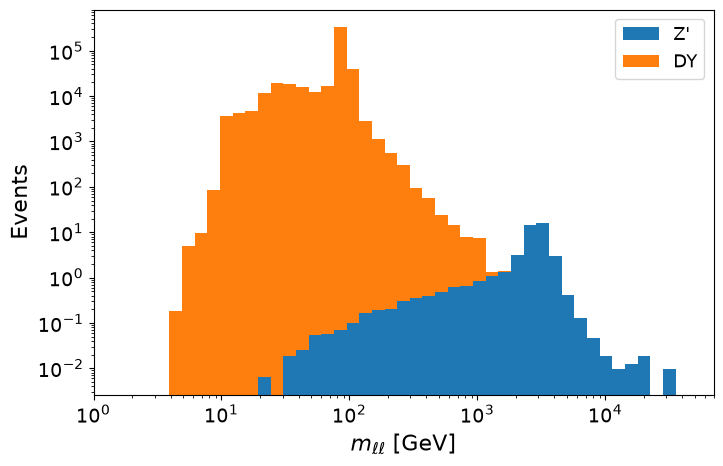

Background integral = 480219.06
Signal     integral = 44.14


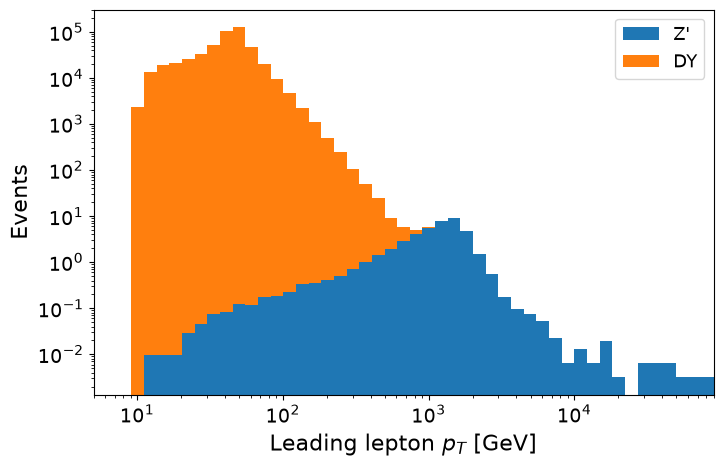

Background integral = 480219.06
Signal     integral = 44.14


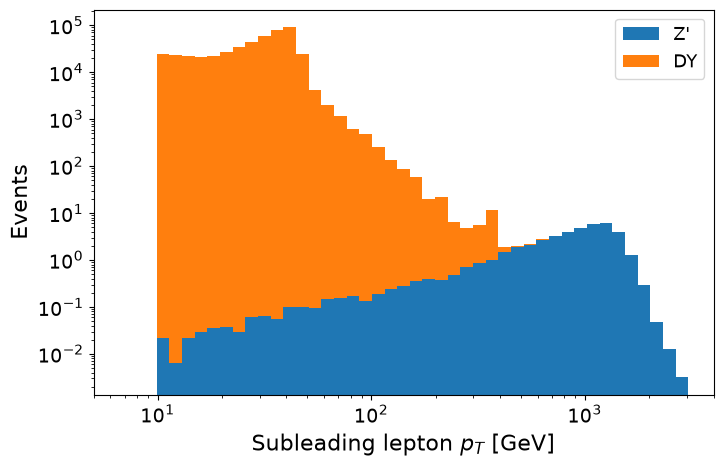

Background integral = 480219.06
Signal     integral = 44.15


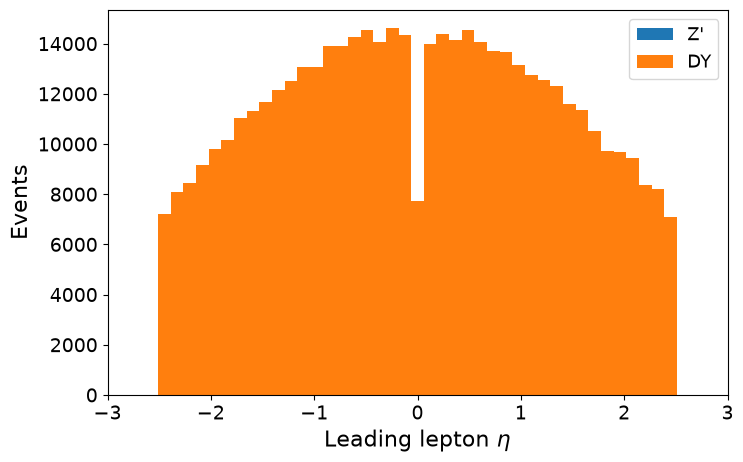

Background integral = 480219.06
Signal     integral = 44.15


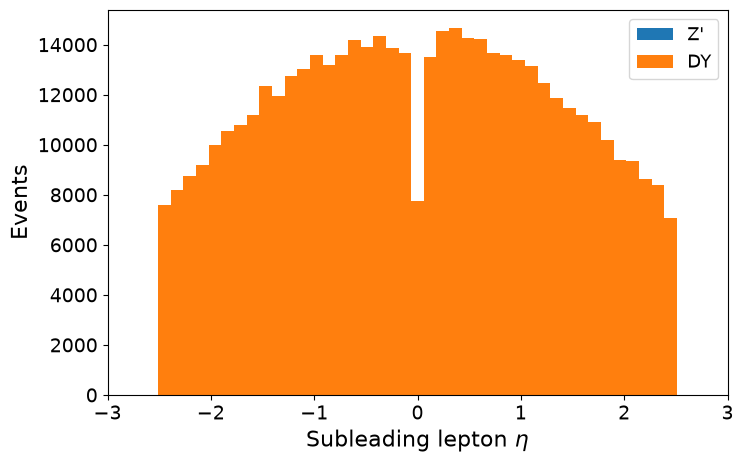

Background integral = 480219.06
Signal     integral = 44.15


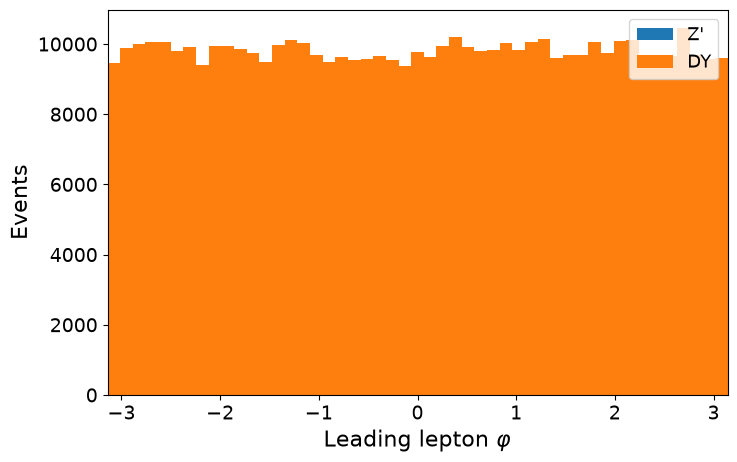

Background integral = 480219.06
Signal     integral = 44.15


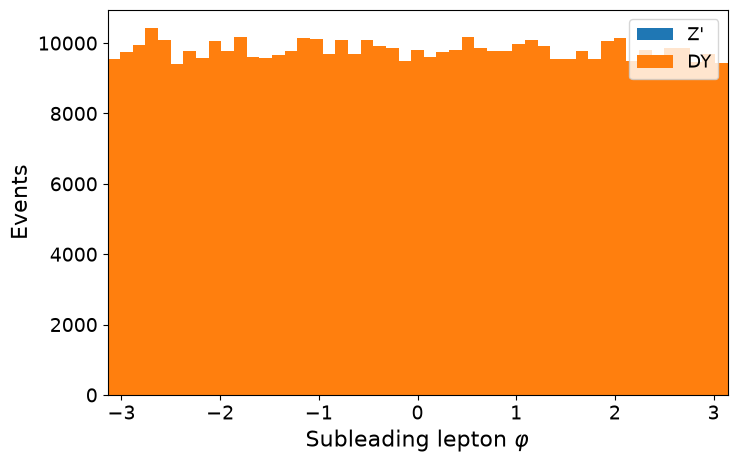

Background integral = 480219.06
Signal     integral = 44.12


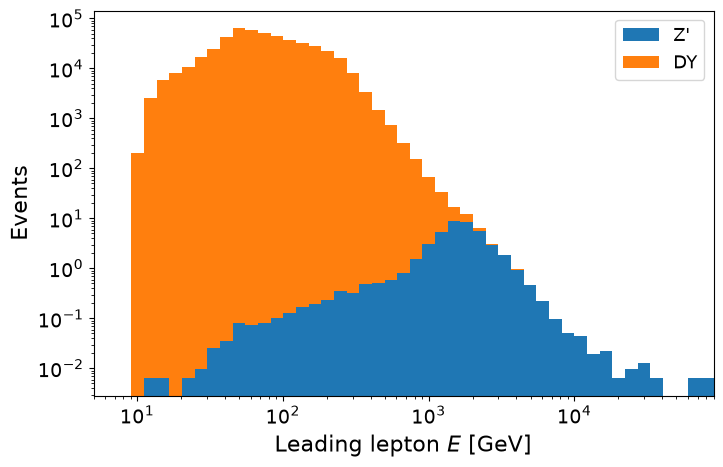

Background integral = 480219.06
Signal     integral = 44.15


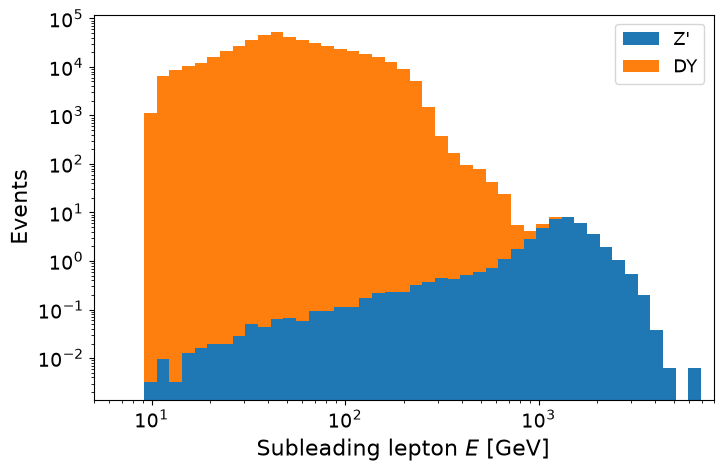

Background integral = 480219.06
Signal     integral = 44.15


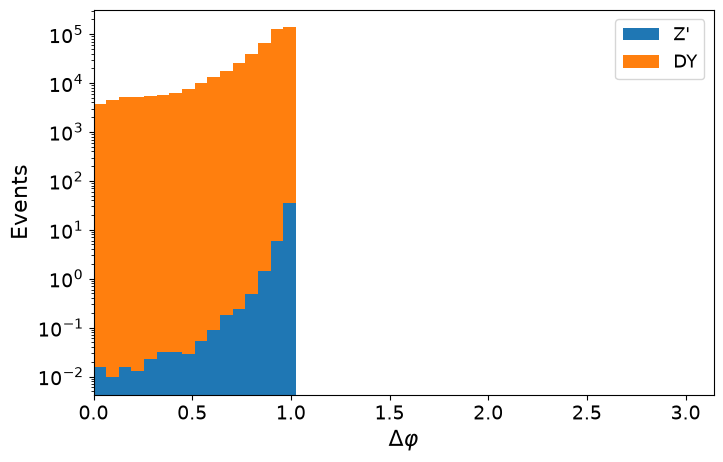

Background integral = 480219.06
Signal     integral = 44.15


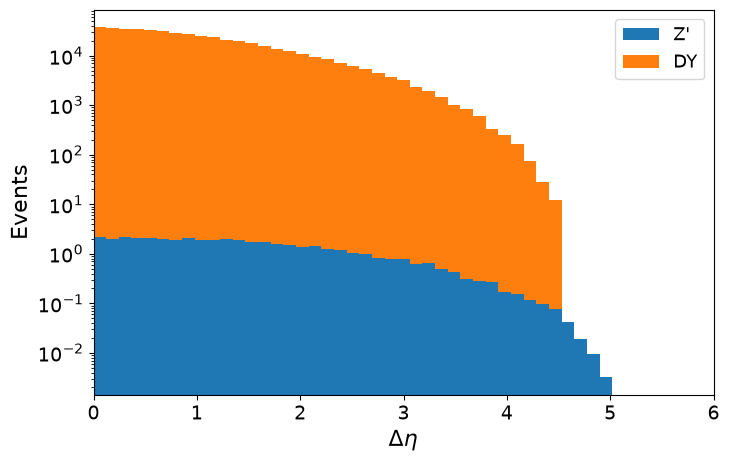

Background integral = 480219.06
Signal     integral = 44.15


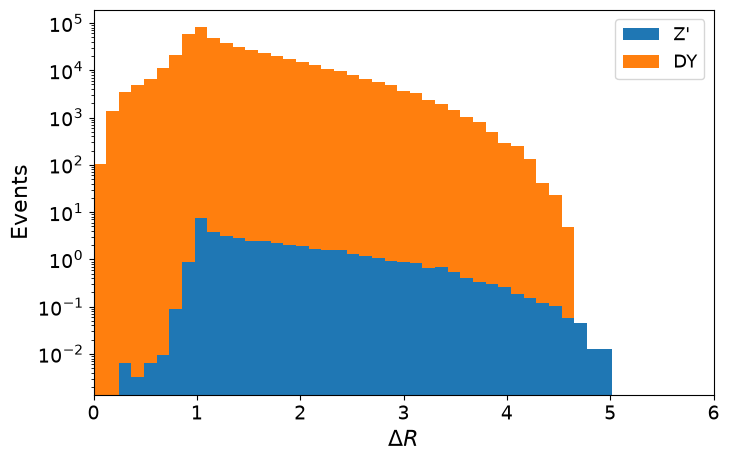

In [60]:
for var, min_val, max_val, xlabel, filename, xlog, ylog in plot_variables:
    plot_variable(signal_df,background_df, var=var, min=min_val, max=max_val, xlabel=xlabel, save=filename, xlog=xlog, ylog=ylog)